## Sales Forcasting - Rossmann Store

The dataset comprises historical sales data for 1,115 Rossmann stores, including additional contextual information such as promotions, holidays, and competition. The primary objective is to forecast the “Sales” column for the test set.

To achieve this, we will develop predictive models using <span style="color:crimson;"> Linear Regression, XGBoost,</span>  and a time-series forecasting approach with the <span style="color:crimson;">Prophet</span> model. The aim is to compare the performance of these models and determine which provides the most accurate sales predictions.

Objectives:
* **Forecast Future Sales:** Predict sales to support data-driven decision-making.
* **Uncover Actionable Insights:** Analyze the impact of factors such as promotions, holidays, and competition on sales trends.
* **Provide Business Recommendations:** Offer strategic guidance on resource allocation and operational planning.

***

In [50]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

/kaggle/input/rossmann-store-sales/store.csv
/kaggle/input/rossmann-store-sales/train.csv
/kaggle/input/rossmann-store-sales/test.csv


In [51]:
store = pd.read_csv('/kaggle/input/rossmann-store-sales/store.csv')
test = pd.read_csv('/kaggle/input/rossmann-store-sales/test.csv')
train = pd.read_csv('/kaggle/input/rossmann-store-sales/train.csv', low_memory=False)

## 1. Data Cleaning

In [52]:
print(store.info())
print(test.info())
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
-

Null values only in the store set

In [53]:
columns_in_train_not_test = set(train.columns) - set(test.columns)

columns_in_test_not_train = set(test.columns) - set(train.columns)

print("Columns in train but not in test:", columns_in_train_not_test)
print("Columns in test but not in train:", columns_in_test_not_train)

Columns in train but not in test: {'Sales', 'Customers'}
Columns in test but not in train: {'Id'}


In [54]:
test=test.drop(columns=['Id'])
train=train.drop(columns=['Customers'])

The goal of the project is predicting sales in the test set, we will be dropping 'Costumers' column from the *train* set, as it's not present in the *test* set, it won't be useful for making predictions.

Id is dropped too as it adds no value to sales predictions

In [55]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [56]:
store['Promo2'].value_counts()

Promo2
1    571
0    544
Name: count, dtype: int64

In [57]:
store[store['Promo2']==0].sum()

Store                                                                   302209
StoreType                    ccaaaaaaadcdddaccdadaddaaddaacaaddadaabaaadadd...
Assortment                   acaacacacaaacccaaaaaacacaccacccaccaaacaaaacaca...
CompetitionDistance                                                  3549840.0
CompetitionOpenSinceMonth                                               2875.0
CompetitionOpenSinceYear                                              795613.0
Promo2                                                                       0
Promo2SinceWeek                                                            0.0
Promo2SinceYear                                                            0.0
PromoInterval                                                                0
dtype: object

We can observe that Promo2SinceWeek and Promo2SinceYear are missing data for when Promo2 is null, we can assign these fields 0 values.

In [58]:
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(2 * store['CompetitionDistance'].max())

store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(0)
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(0)

store['Promo2SinceWeek'] = store['Promo2SinceWeek'].fillna(0)
store['Promo2SinceYear'] = store['Promo2SinceYear'].fillna(0)
store['PromoInterval'] = store['PromoInterval'].fillna(0)
test['Open'] = test['Open'].fillna(0)

Stores with Null competition distance imply no competition nearby, replacing it with 0 would imply competition is next door, instead we'll replace it with 2x of furthest competition.

In [59]:
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

In [60]:
train = pd.merge(train, store, on='Store', how='left')
test = pd.merge(test, store, on='Store', how='left')

In [61]:
sd = train.sample(frac=0.1, random_state=1)

Sampling 10% of the training data for visulisations as the full set has over 1 million rows

## 2. Visualisation

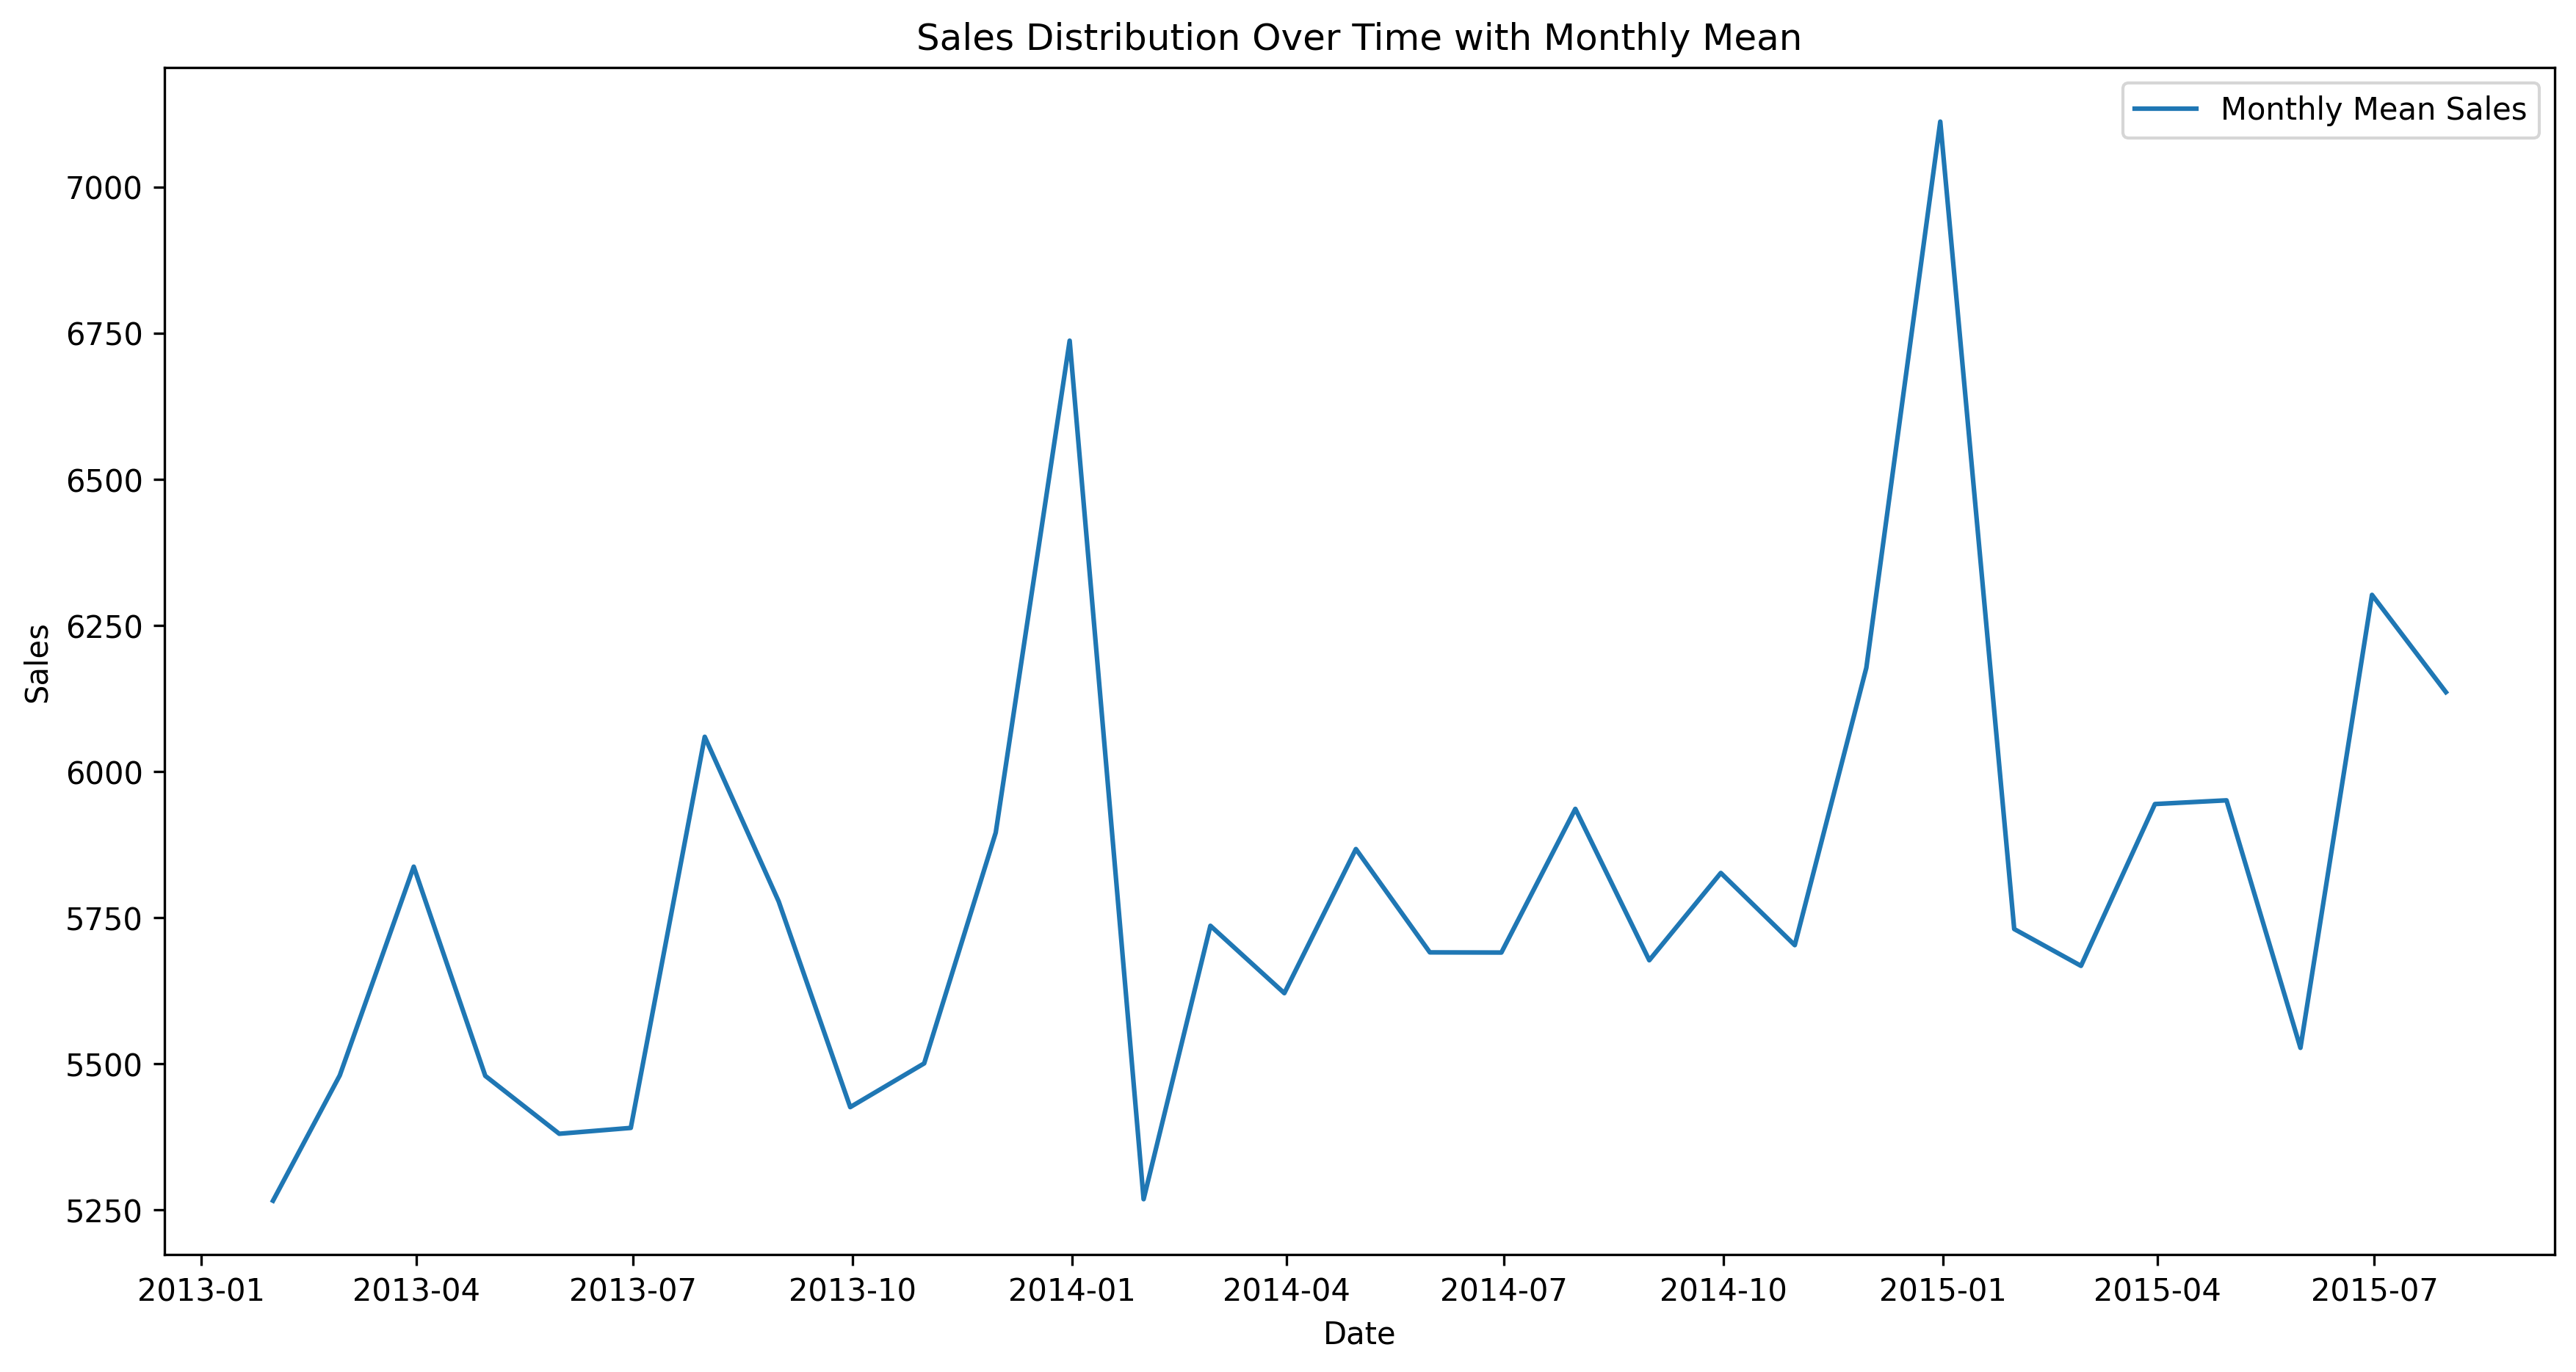

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

monthly_sales = sd.resample('M', on='Date')['Sales'].mean().reset_index()

plt.figure(figsize=(14, 7), dpi=300)
sns.lineplot(data=monthly_sales, x='Date', y='Sales', label='Monthly Mean Sales')
plt.title('Sales Distribution Over Time with Monthly Mean')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

This time series graph shows monthly sales data,sales peak around **January** around 8,500 units, with an overall upward trend despite fluctuations. Between peaks, sales usually range from 6,500 to 7,500 units, with occasional dips in October-November. These patterns suggest seasonality, likely driven by post-holiday sales or promotions.

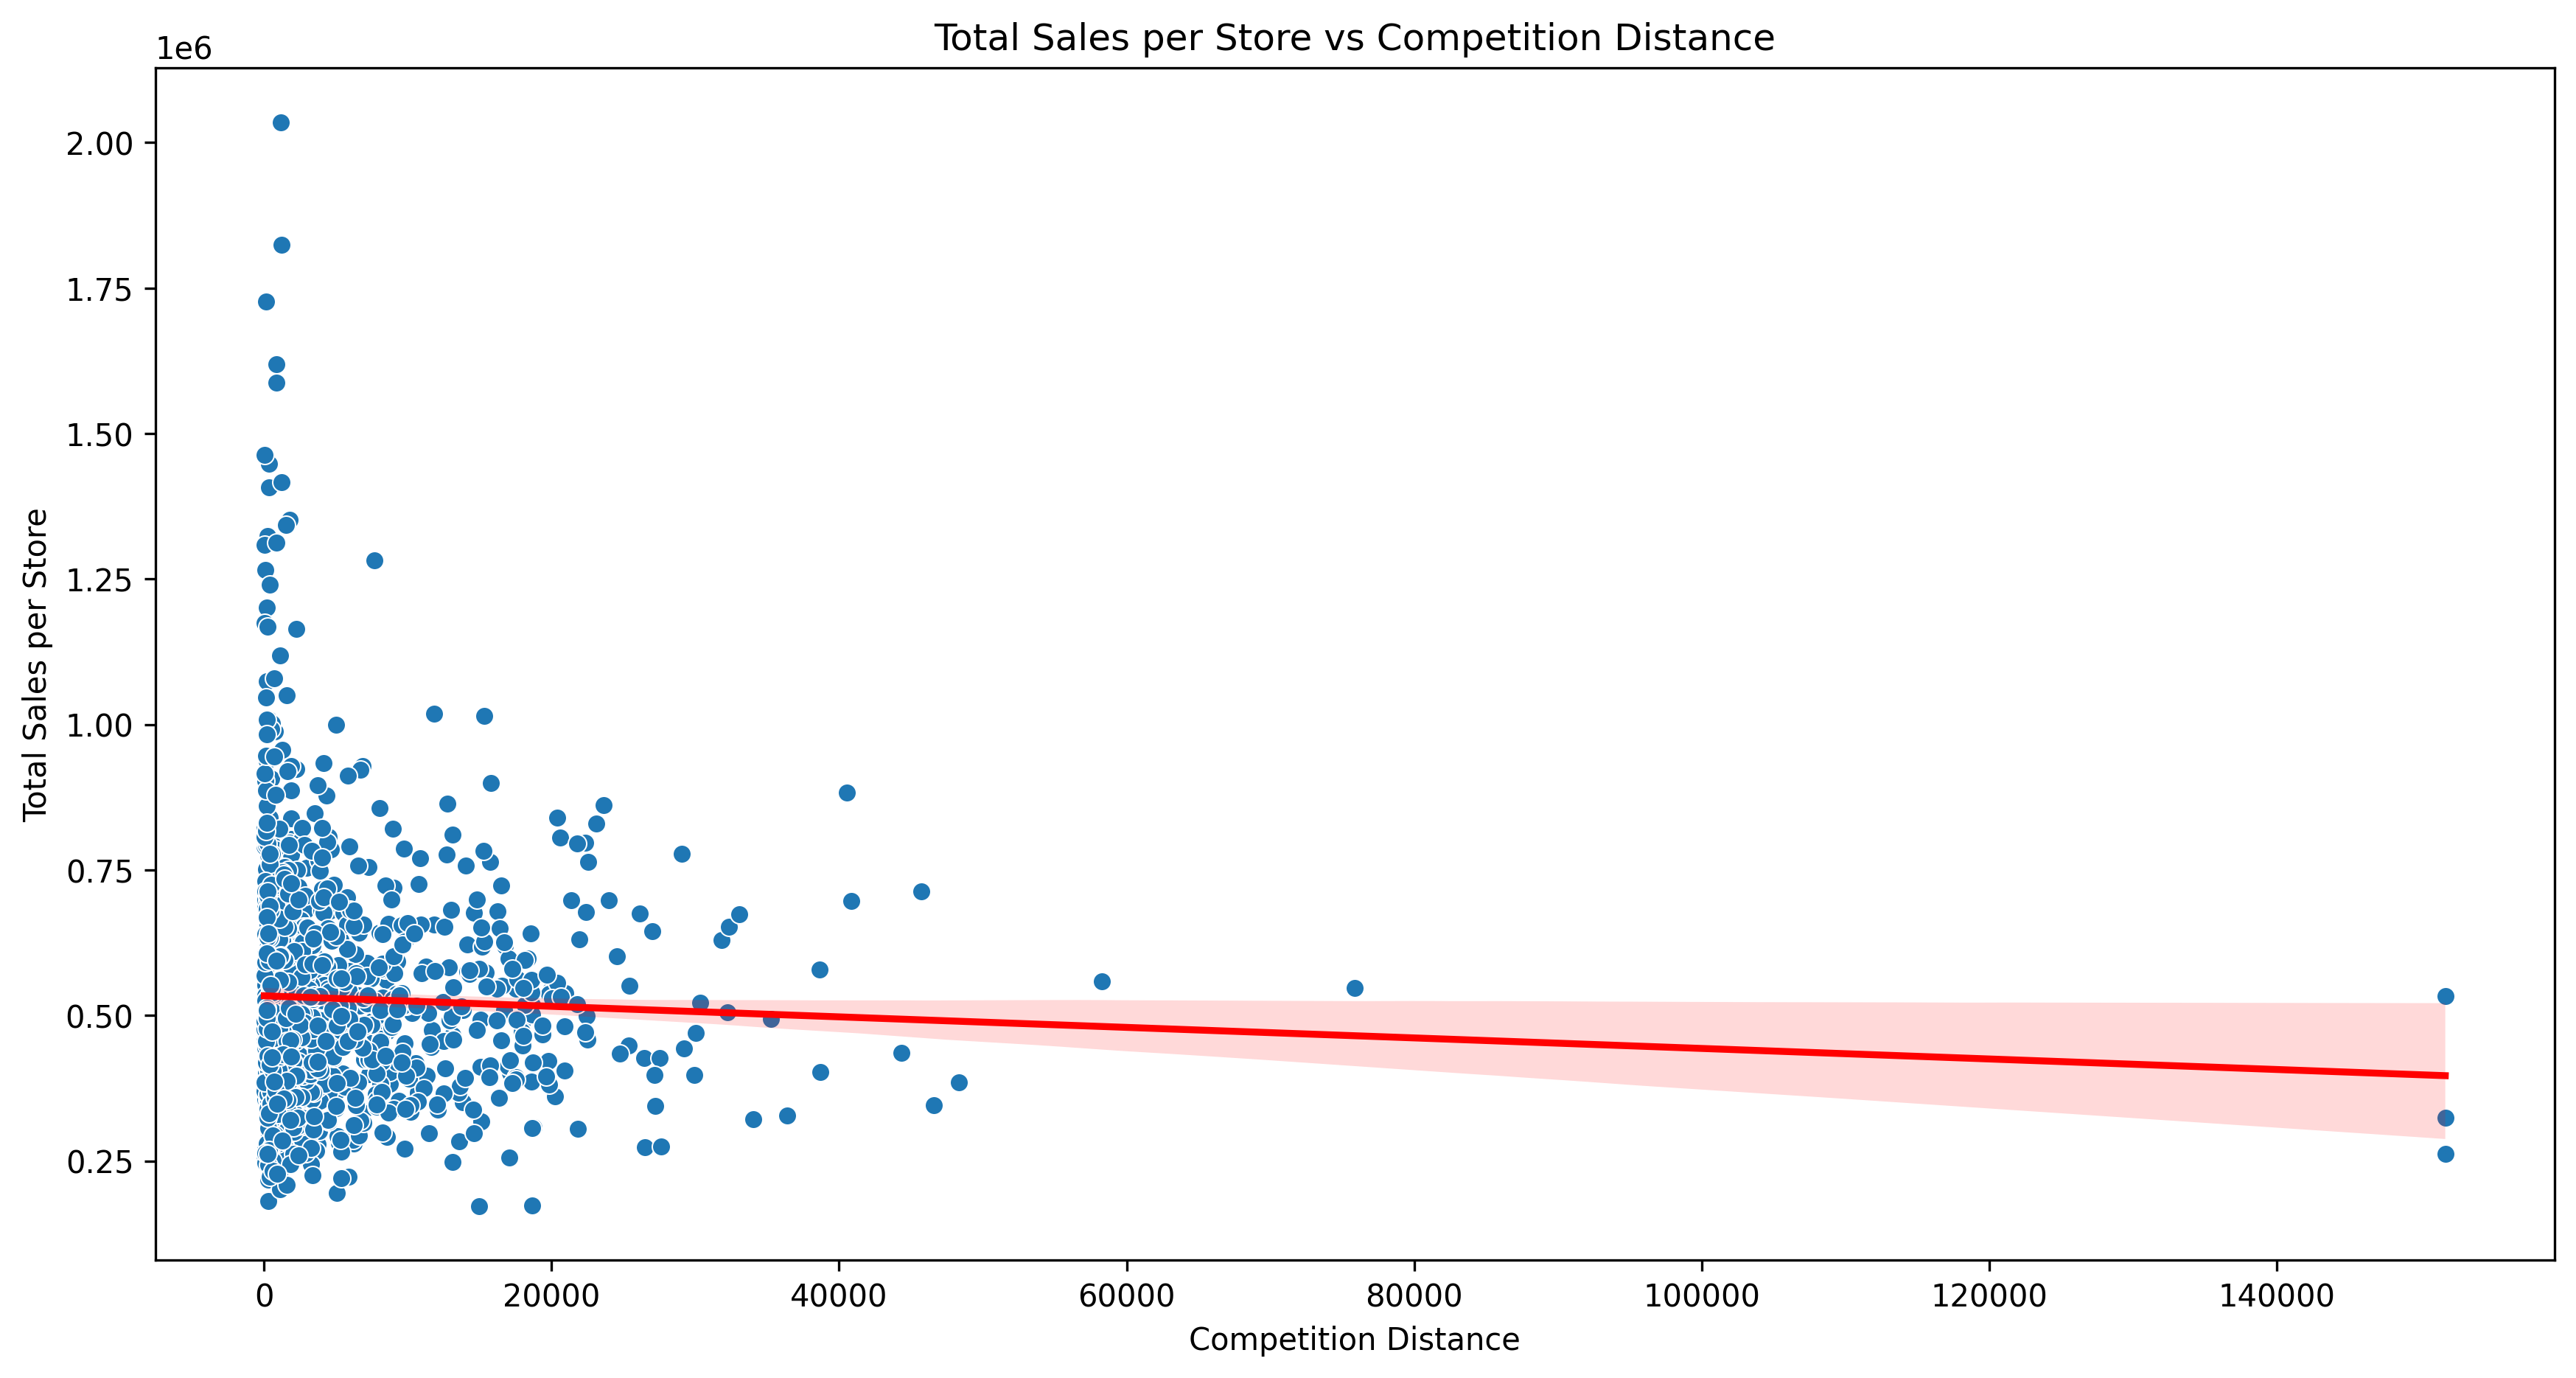

In [63]:
store_sales = sd.groupby('Store').agg({
    'Sales': 'sum',  
    'CompetitionDistance': 'mean' 
}).reset_index()

plt.figure(figsize=(14, 7),dpi=300)
sns.scatterplot(x='CompetitionDistance', y='Sales', data=store_sales)
sns.regplot(x='CompetitionDistance', y='Sales', data=store_sales, scatter=False, color='red')
plt.title("Total Sales per Store vs Competition Distance")
plt.xlabel('Competition Distance')
plt.ylabel('Total Sales per Store')
plt.show()

* Most stores are clustered close to the competition, highest and lowest performing stores can be found here.
* There is a slight negative correlation, distance from competiton increases, sales tend to slightly decrease

This suggest that proximity to competition isn't necessarily bad for business, possibly because these are highly dense and populated areas that can support multiple stores.

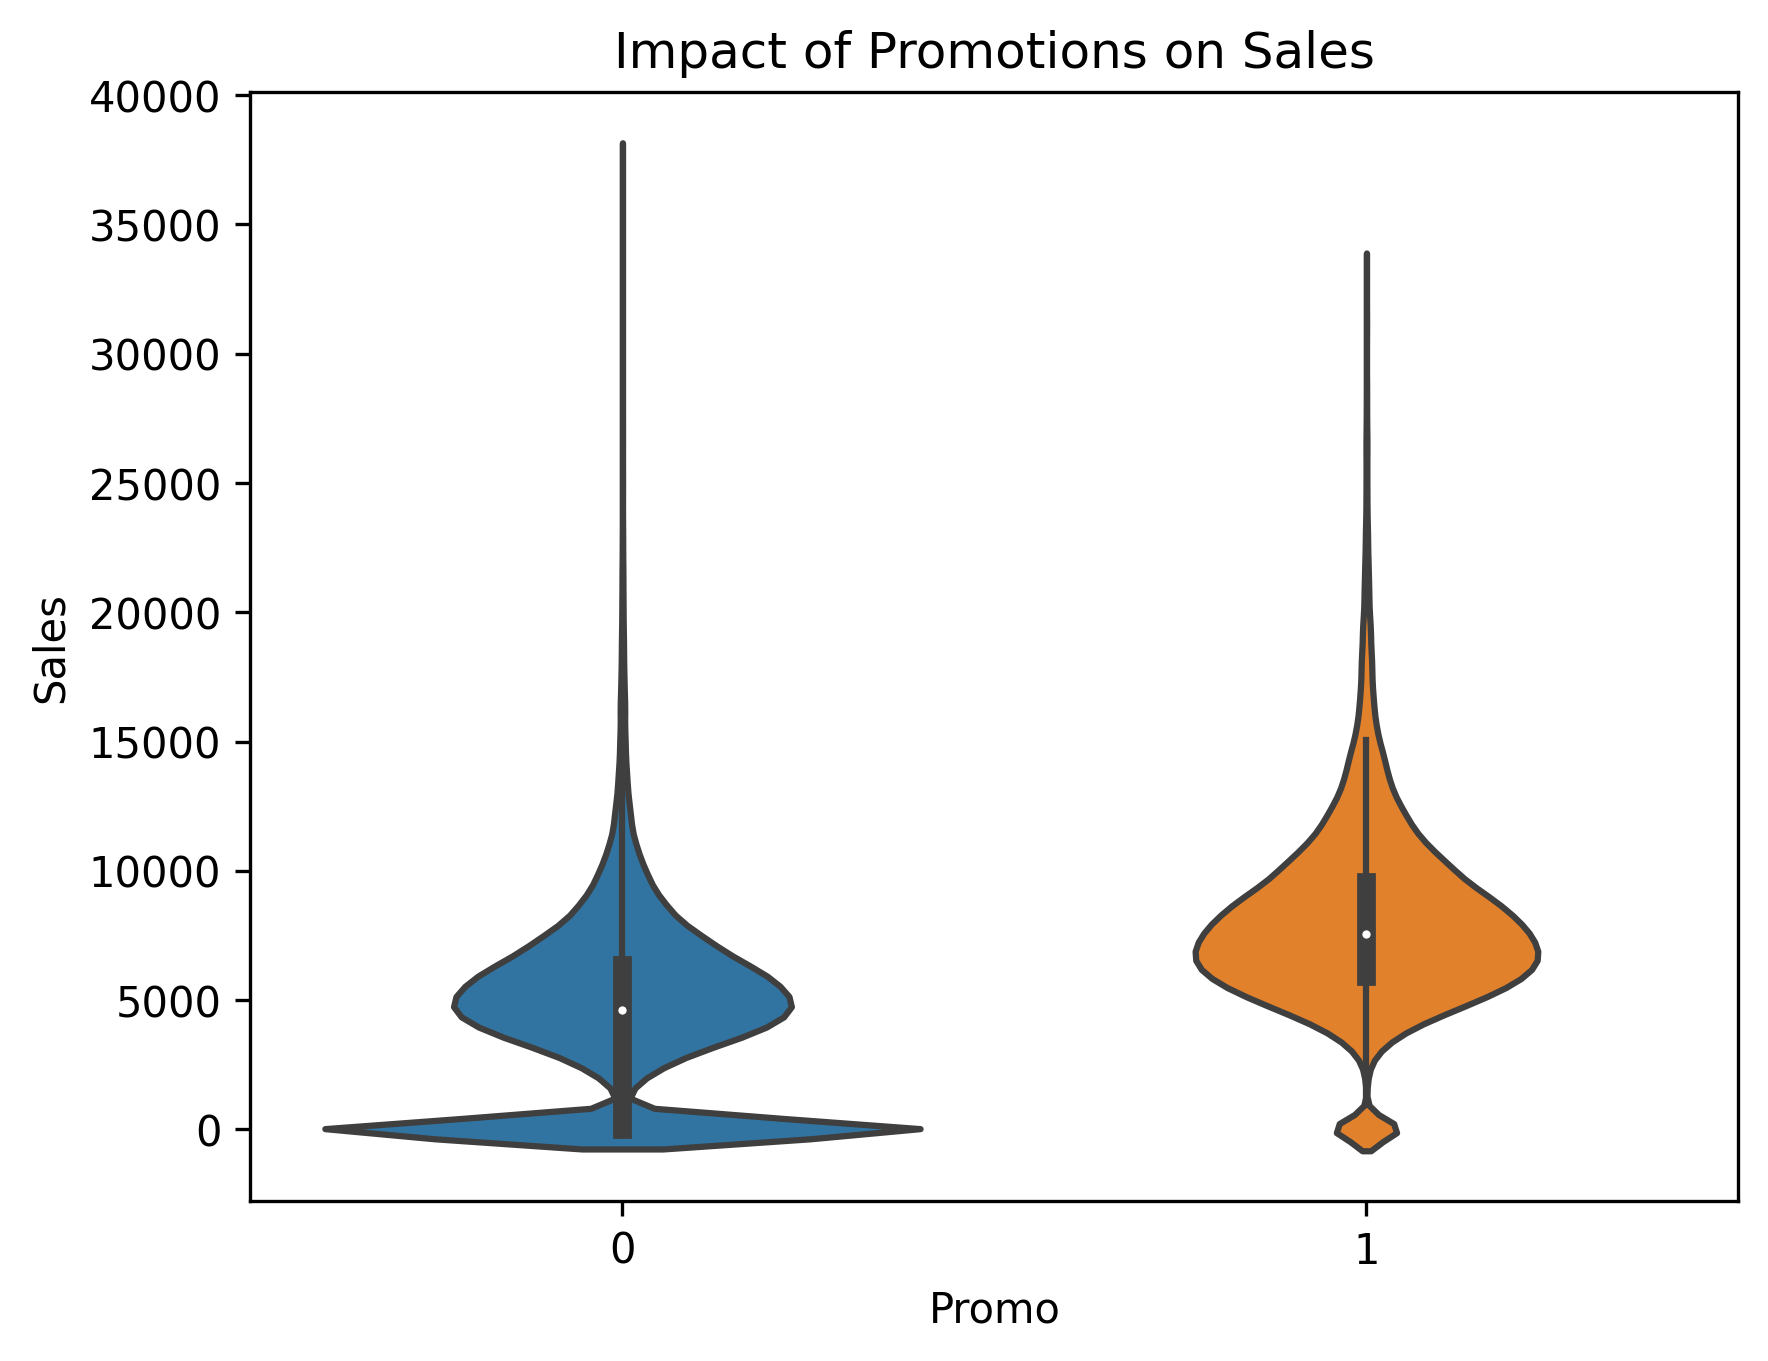

In [64]:
plt.figure(dpi=300) 
sns.violinplot(x='Promo', y='Sales', data=sd)
plt.title("Impact of Promotions on Sales")
plt.show()

The violin plot compares sales distributions during promotional (1) and non-promotional (0) periods.

* Sales with promotions (orange violin) are generally higher than without promotions (blue violin)
* The median sales appear to be around 7,000-8,000 during promotions vs around 4,000-5,000 without promotions
* Non-promotional periods (0) display lower, more dispersed sales.
* Promotions seem to provide more consistent sales performance (less variance)

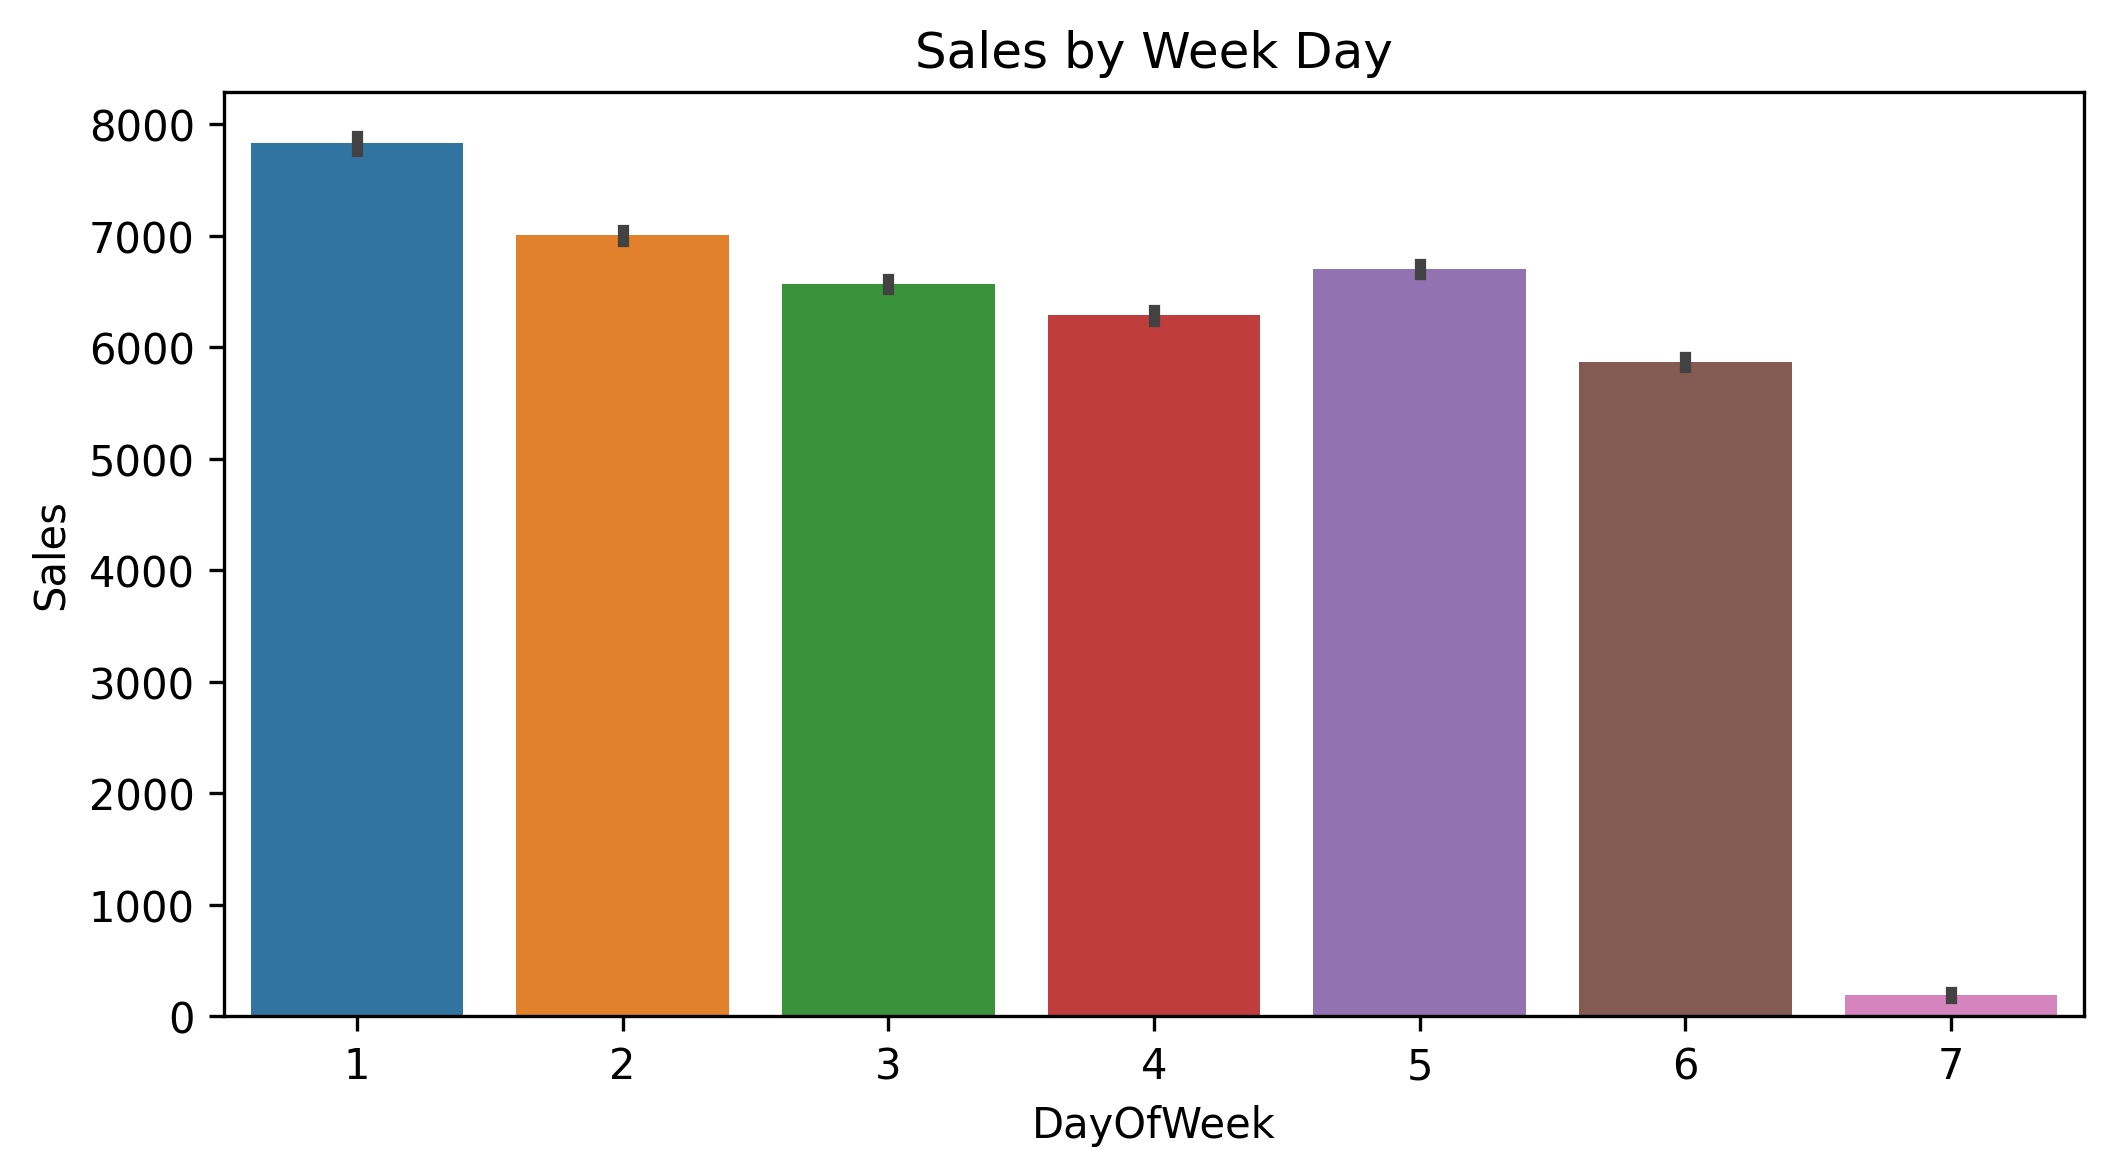

In [65]:
plt.figure(figsize=(8,4),dpi=300) 
sns.barplot(x='DayOfWeek', y='Sales', data=sd)
plt.title("Sales by Week Day")
plt.show()

Sales peak first day of the week, gradually tapering off with the exception of Friday. Sales are dramatically cut on Sunday indicating that most stores are closed.

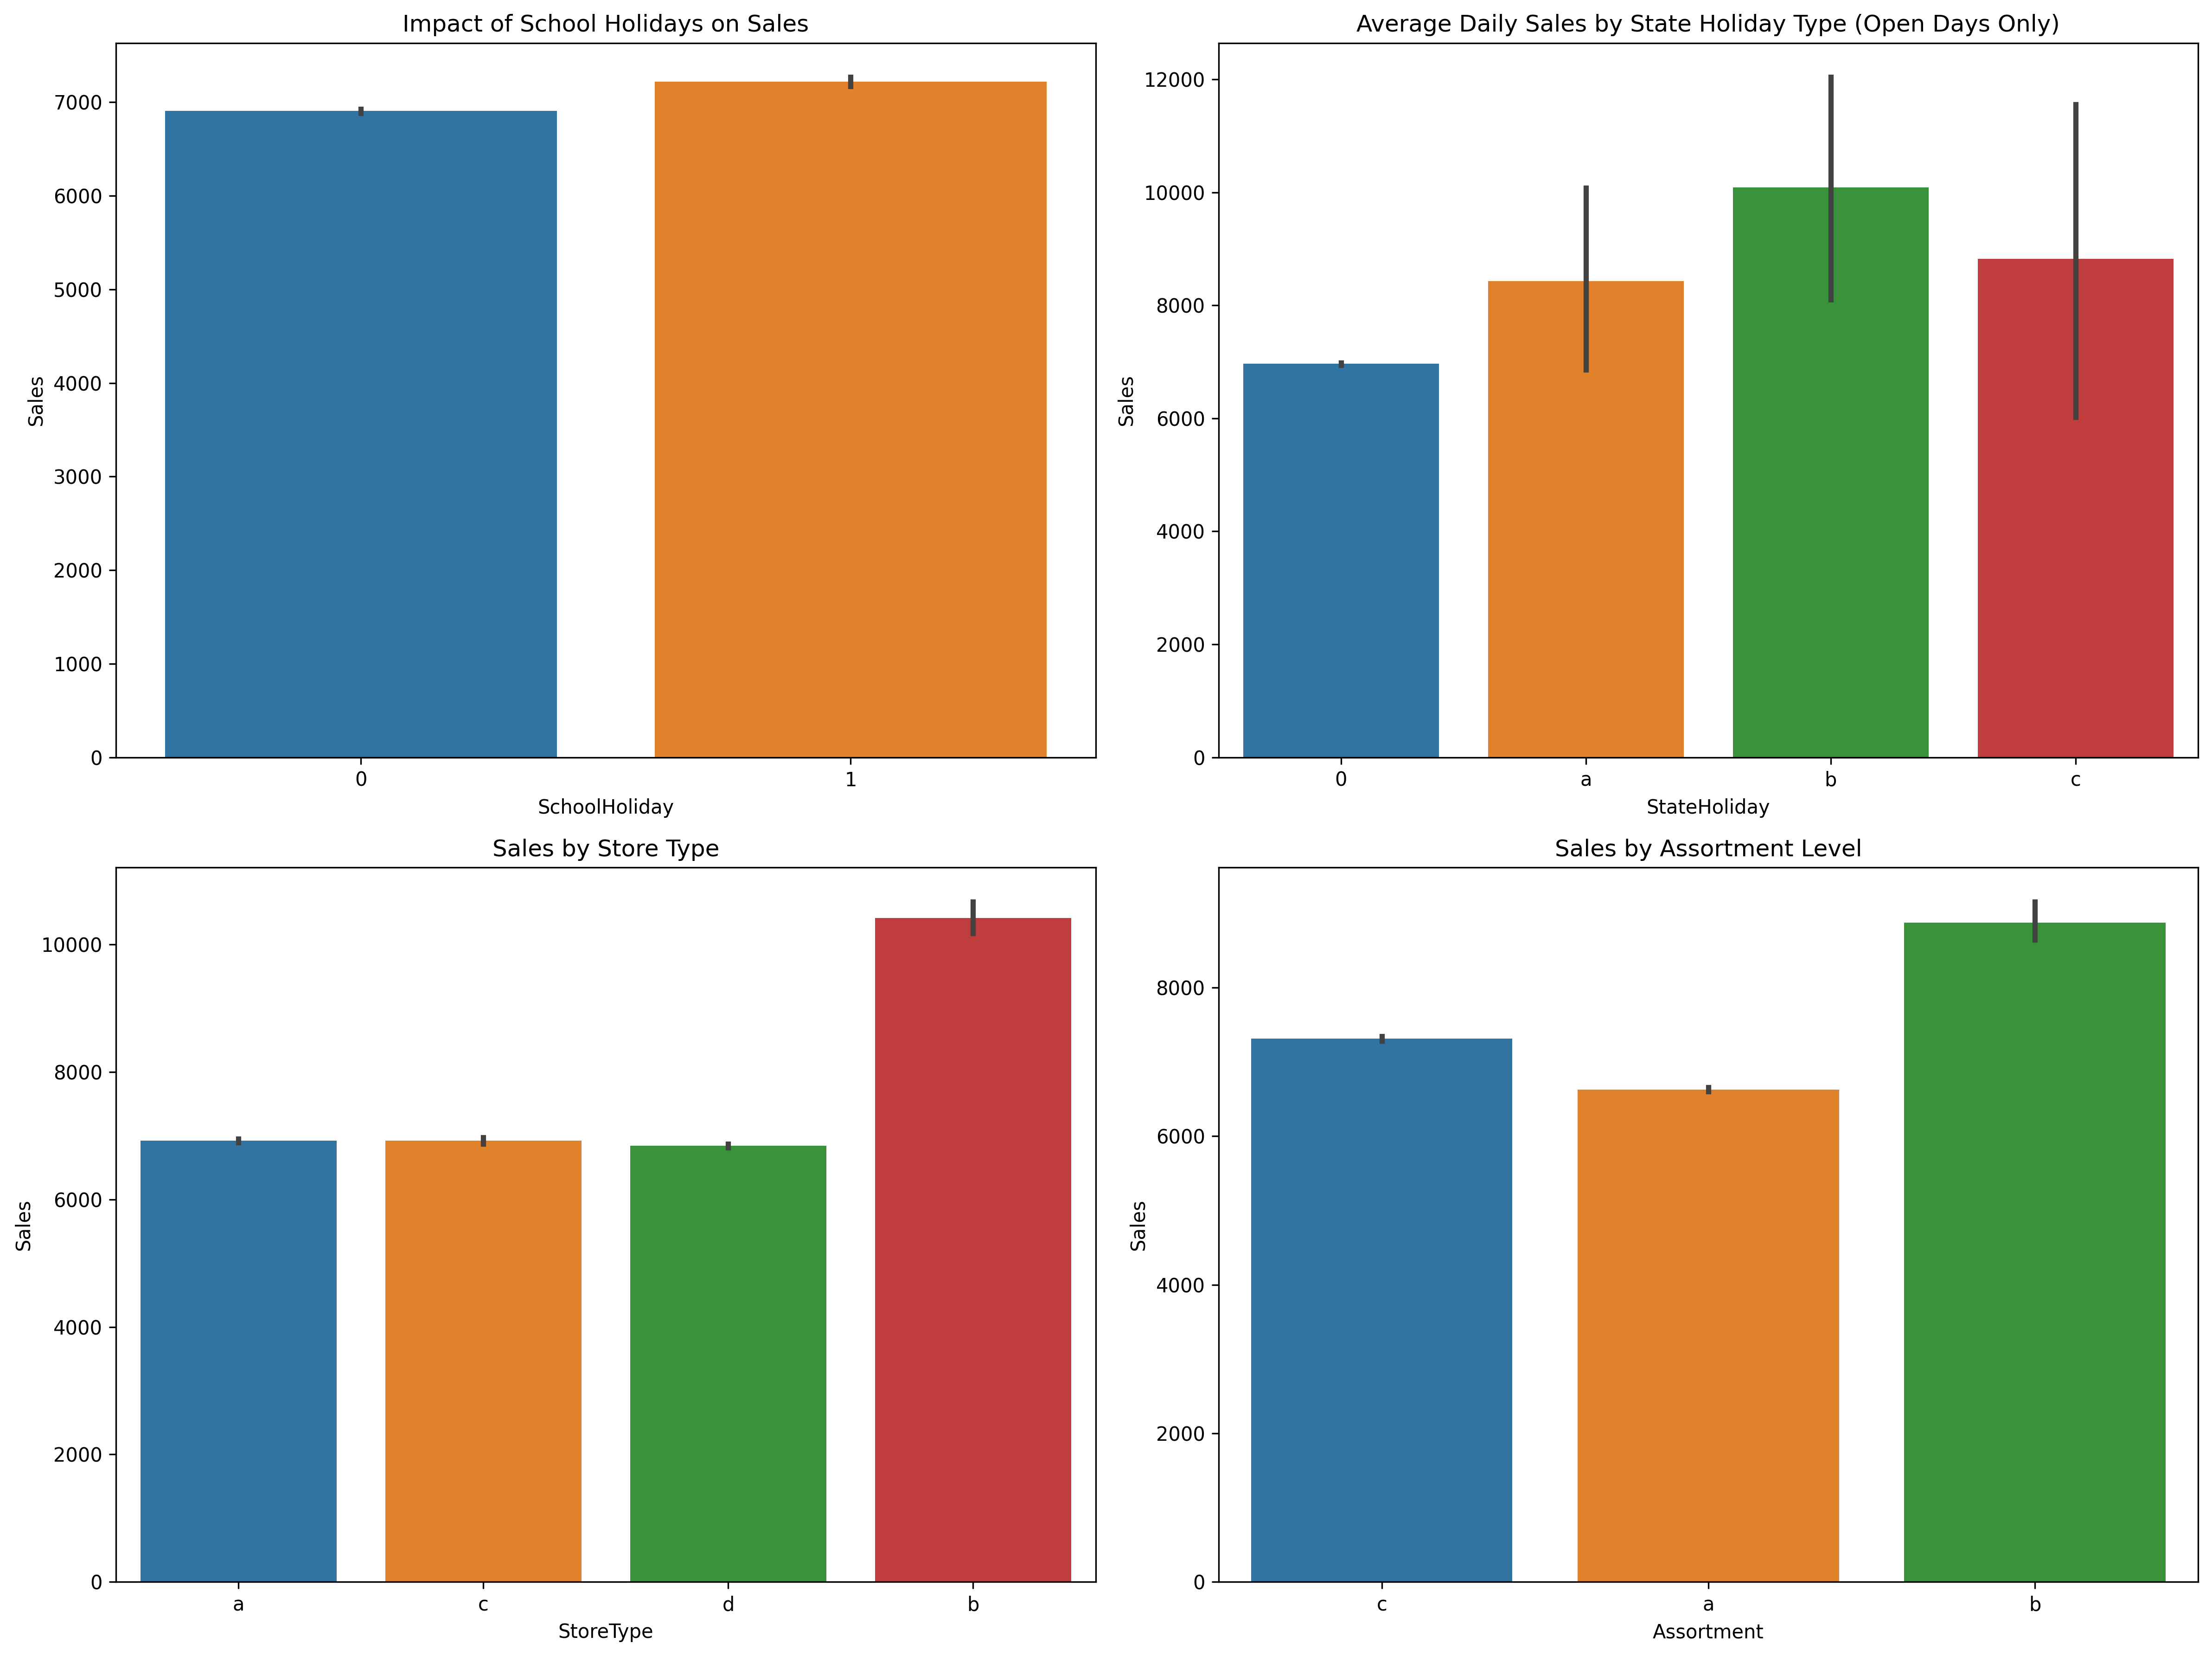

In [66]:
avg_sales = sd[sd['Open'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)

# Plot 1
sns.barplot(ax=axes[0, 0], x='SchoolHoliday', y='Sales', data=avg_sales)
axes[0, 0].set_title("Impact of School Holidays on Sales")

# Plot 2
sns.barplot(ax=axes[0, 1], x='StateHoliday', y='Sales', data=avg_sales)
axes[0, 1].set_title("Average Daily Sales by State Holiday Type (Open Days Only)")

# Plot 3
sns.barplot(ax=axes[1, 0], x='StoreType', y='Sales', data=avg_sales)
axes[1, 0].set_title("Sales by Store Type")

# Plot 4
sns.barplot(ax=axes[1, 1], x='Assortment', y='Sales', data=avg_sales)
axes[1, 1].set_title("Sales by Assortment Level")

plt.tight_layout()
plt.show()

*  School holidays have a minor positive effect on sales
*  Easter holidays (b) generate the highest average daily sales, Public holidays (a) and Christmas (c) also show elevated sales compared to non-holiday periods
*  Store type 'b' significantly outperforms other store types, with nearly 50% higher sales
*  Extra assortment (b) generates the highest sales, Extended assortment (c) shows moderate sales and Basic assortment (a) has the lowest sales, this suggests that stores with wider product ranges tend to perform better


Overall, these graphs indicate that sales performance is most strongly influenced by **store type** and **assortment level**, with holiday periods providing additional boosts to sales. The data suggests that expanding product assortment and focusing on high-performing store types (type 'b') could be effective strategies for increasing sales.

Summary of Insights to Deliver:

1. 	Sales Trends: Identify seasonality, holidays, and high-performing months.
2. 	Promotions: Highlight their impact on sales.
3. 	Competition: Understand how competitor proximity affects performance.
4. 	Store Types/Assortments: Pinpoint which stores and assortments perform best.
5. 	Closures: Analyze reasons for closures and recommend operational changes.

***

## 3. Data preprocessing

In [68]:
def date_features(df):
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week'] = df['Date'].dt.isocalendar().week
    df['Day'] = df['Date'].dt.day

date_features(train)
date_features(test)

In [69]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 21 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Open                       1017209 non-null  int64         
 5   Promo                      1017209 non-null  int64         
 6   StateHoliday               1017209 non-null  object        
 7   SchoolHoliday              1017209 non-null  int64         
 8   StoreType                  1017209 non-null  object        
 9   Assortment                 1017209 non-null  object        
 10  CompetitionDistance        1017209 non-null  float64       
 11  CompetitionOpenSinceMonth  1017209 no

In [70]:
train[(train.Open==0)].shape

(172817, 21)

In [71]:
print("Closed stores and days which didn't have any sales won't be counted into the forecasts.")
train = train[(train['Sales'] > 0)]

print("In total: ", train.shape)

Closed stores and days which didn't have any sales won't be counted into the forecasts.
In total:  (844338, 21)


In [72]:
train.sample(5)

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Week,Day
450000,326,6,2014-05-24,5666,1,0,0,0,d,a,...,5.0,2015.0,1,31.0,2013.0,"Feb,May,Aug,Nov",2014,5,21,24
43192,823,2,2015-06-23,5292,1,0,0,0,a,c,...,11.0,2010.0,0,0.0,0.0,0,2015,6,26,23
649836,577,2,2013-11-26,5582,1,0,0,0,a,c,...,0.0,0.0,1,35.0,2012.0,"Mar,Jun,Sept,Dec",2013,11,48,26
500029,180,3,2014-04-09,5773,1,0,0,0,d,a,...,9.0,2010.0,0,0.0,0.0,0,2014,4,15,9
508526,872,3,2014-04-02,9296,1,1,0,0,a,c,...,9.0,2014.0,1,23.0,2015.0,"Mar,Jun,Sept,Dec",2014,4,14,2


In [73]:
def process_promo_features(df):
    df['Promo2SinceDate'] = pd.to_datetime(
        df['Promo2SinceYear'].astype(str) + df['Promo2SinceWeek'].astype(str) + '0',
        format='%Y%U%w',
        errors='coerce'
    )
    df['Promo2Active'] = (df['Date'] >= df['Promo2SinceDate']).astype(int)
    df['PromoDuringHoliday'] = (df['Promo'] & (df['StateHoliday'] != '0')).astype(int)

process_promo_features(train)
process_promo_features(test)

In [74]:
from sklearn.preprocessing import StandardScaler

def preprocess_data(df):
    df = df.copy()
    
    # Cyclical atetime features
    for col in ['Date', 'Promo2SinceDate']:
        if col in df.columns:
            for unit, max_val in [('day', 31), ('month', 12)]:
                angle = 2 * np.pi * getattr(df[col].dt, unit) / max_val
                df[f'{col}_sin_{unit}'] = np.sin(angle)
                df[f'{col}_cos_{unit}'] = np.cos(angle)
    
    # One-hot encoding
    df = pd.get_dummies(df, columns=['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], drop_first=True)
    
    # Competition features
    df['CompetitionOpen'] = 12 * (df['CompetitionOpenSinceYear'] - df['Year']) + \
                           (df['CompetitionOpenSinceMonth'] - df['Month'])
    # Promo features and scaling
    df['PromoTotal'] = df['Promo'] + df['Promo2']
    
    # Numerical features scaling
    scaler = StandardScaler()
    for col in ['CompetitionDistance', 'CompetitionOpen']:
        if col in df.columns:
            df[col] = scaler.fit_transform(df[col].fillna(df[col].mean()).values.reshape(-1, 1))
    
    # Drop columns
    drop_cols = ['Date', 'Promo2SinceDate', 'CompetitionOpenSinceMonth', 
                'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear']
    return df.drop(columns=[c for c in drop_cols if c in df.columns])

trainEn = preprocess_data(train)
testEn = preprocess_data(test)

In [75]:
# One hot encoding creates columns, such as christmas holiday in train set, but it does not exist in the
# test set which only contains October and September data, we add missing columns here and fill them with 0

train_columns = set(trainEn.columns) - {'Sales'}
test_columns = set(testEn.columns)

missing_columns = train_columns - test_columns

for col in missing_columns:
    testEn[col] = False

testEn = testEn[trainEn.columns.drop('Sales')]

In [76]:
# These represent stores that didn't participate in Promo2
cyclical_cols = ['Promo2SinceDate_sin_day', 'Promo2SinceDate_cos_day',
                 'Promo2SinceDate_sin_month', 'Promo2SinceDate_cos_month']
trainEn[cyclical_cols] = trainEn[cyclical_cols].fillna(0)

cyclical_cols = ['Promo2SinceDate_sin_day', 'Promo2SinceDate_cos_day',
                 'Promo2SinceDate_sin_month', 'Promo2SinceDate_cos_month']
testEn[cyclical_cols] = testEn[cyclical_cols].fillna(0)

## 4. Modelling

In [77]:
# Training data: all years except the last
X_train = trainEn[trainEn['Year'] < 2015].drop(['Sales'], axis=1)
y_train = trainEn[trainEn['Year'] < 2015]['Sales']

# Validation data: last year in trainEn
X_val = trainEn[trainEn['Year'] == 2015].drop(['Sales'], axis=1)
y_val = trainEn[trainEn['Year'] == 2015]['Sales']

X_test = testEn

### 4.1 Linear Regression

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_val_lr = lr_model.predict(X_val)

mae_lr = mean_absolute_error(y_val, y_pred_val_lr)
rmse_lr = mean_squared_error(y_val, y_pred_val_lr, squared=False)

print(f"Linear Regression - Validation MAE: {mae_lr}")
print(f"Linear Regression - Validation RMSE: {rmse_lr}")

y_pred_test_lr = lr_model.predict(X_test)

Linear Regression - Validation MAE: 1946.0236423991164
Linear Regression - Validation RMSE: 2661.5743085092035


In [79]:
# Baseline: Mean sales prediction
baseline_prediction = y_val.mean()
baseline_mae = mean_absolute_error(y_val, [baseline_prediction] * len(y_val))
baseline_rmse = mean_squared_error(y_val, [baseline_prediction] * len(y_val), squared=False)
print(f"Baseline MAE: {baseline_mae}, Baseline RMSE: {baseline_rmse}")

Baseline MAE: 2248.3234536020777, Baseline RMSE: 3034.126169666448


In [80]:
mae_percent = (mae_lr / y_val.mean()) * 100
rmse_percent = (rmse_lr / y_val.mean()) * 100
print(f"MAE as % of mean sales: {mae_percent:.2f}%")
print(f"RMSE as % of mean sales: {rmse_percent:.2f}%")

MAE as % of mean sales: 27.45%
RMSE as % of mean sales: 37.55%


### 4.2 XGBoost

In [81]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

xgb_model = XGBRegressor(
    n_estimators=1000,          
    learning_rate=0.1,         
    max_depth=8,               
    subsample=0.9,           
    colsample_bytree=0.9,       
    reg_alpha=0.1,              
    reg_lambda=1.0,             
    min_child_weight=3,         
    random_state=12,           
    early_stopping_rounds=50   
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  
    verbose=200                  
)

y_pred_val_xgb = xgb_model.predict(X_val)

mae_xgb = mean_absolute_error(y_val, y_pred_val_xgb)
rmse_xgb = mean_squared_error(y_val, y_pred_val_xgb, squared=False)

print(f"XGBoost - Validation MAE: {mae_xgb}")
print(f"XGBoost - Validation RMSE: {rmse_xgb}")

[0]	validation_0-rmse:2943.34230
[200]	validation_0-rmse:1319.95455
[400]	validation_0-rmse:1193.40976
[600]	validation_0-rmse:1162.03692
[800]	validation_0-rmse:1145.26385
[999]	validation_0-rmse:1138.11760
XGBoost - Validation MAE: 786.7390577999919
XGBoost - Validation RMSE: 1138.0325687863306


In [82]:
mae_percent = (mae_xgb / y_val.mean()) * 100
rmse_percent = (rmse_xgb / y_val.mean()) * 100
print(f"MAE as % of mean sales: {mae_percent:.2f}%")
print(f"RMSE as % of mean sales: {rmse_percent:.2f}%")
print(f"Train Score: {(xgb_model.score(X_train, y_train))*100:.2f}%")

MAE as % of mean sales: 11.10%
RMSE as % of mean sales: 16.06%
Train Score: 96.35%


In [83]:
X_combined = pd.concat([X_train, X_val], axis=0)
y_combined = np.concatenate([y_train, y_val], axis=0)

# Training the model on combined train and validation data
xgb_model.fit(
    X_combined, y_combined,
    eval_set=[(X_combined, y_combined)],
    verbose=200
)

y_pred_test_xgb = xgb_model.predict(X_test)

[0]	validation_0-rmse:2993.28162
[50]	validation_0-rmse:1807.05421
[100]	validation_0-rmse:1348.80188
[150]	validation_0-rmse:1104.05287
[200]	validation_0-rmse:970.43354
[250]	validation_0-rmse:892.78168
[300]	validation_0-rmse:839.88323
[350]	validation_0-rmse:802.08915
[400]	validation_0-rmse:774.08671
[450]	validation_0-rmse:748.50381
[500]	validation_0-rmse:726.39082
[550]	validation_0-rmse:707.08618
[600]	validation_0-rmse:690.42067
[650]	validation_0-rmse:676.48501
[700]	validation_0-rmse:664.84807
[750]	validation_0-rmse:653.84994
[800]	validation_0-rmse:642.81188
[850]	validation_0-rmse:633.80749
[900]	validation_0-rmse:625.80557
[950]	validation_0-rmse:617.90479
[999]	validation_0-rmse:610.38722


In [84]:
val_results = X_val.copy() 
val_results['Actual_Sales'] = y_val  
val_results['Predicted_Sales'] = y_pred_val_xgb  

val_results['PseudoDate'] = pd.to_datetime(val_results['Year'].astype(str) + '-' + val_results['Month'].astype(str) + '-01')

val_results['Residuals'] = val_results['Actual_Sales'] - val_results['Predicted_Sales']

val_agg = val_results.groupby('PseudoDate')[['Actual_Sales', 'Predicted_Sales']].sum().reset_index()

val_agg['Cumulative_Actual_Sales'] = val_agg['Actual_Sales'].cumsum()
val_agg['Cumulative_Predicted_Sales'] = val_agg['Predicted_Sales'].cumsum()

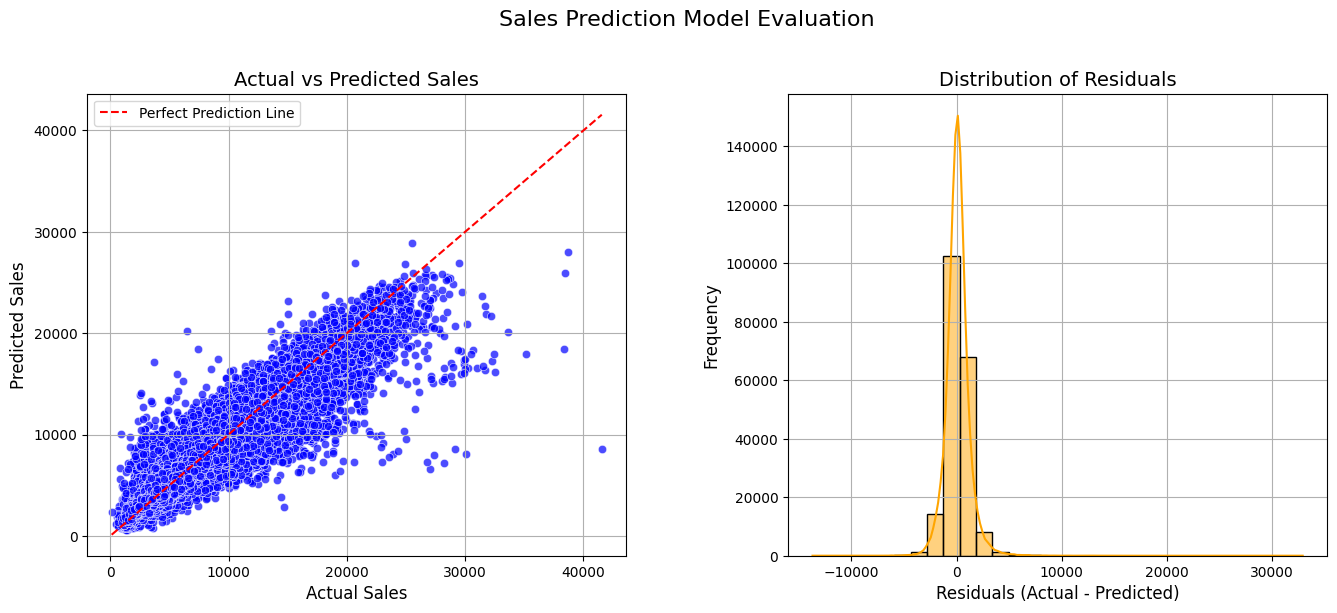

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'wspace': 0.3},dpi=300)

# Subplot 1
sns.scatterplot(
    x=val_results['Actual_Sales'], 
    y=val_results['Predicted_Sales'], 
    alpha=0.7, 
    color='blue', 
    ax=axes[0]
)
axes[0].plot(
    [val_results['Actual_Sales'].min(), val_results['Actual_Sales'].max()],
    [val_results['Actual_Sales'].min(), val_results['Actual_Sales'].max()],
    color='red', linestyle='--', label='Perfect Prediction Line'
)
axes[0].set_title('Actual vs Predicted Sales', fontsize=14)
axes[0].set_xlabel('Actual Sales', fontsize=12)
axes[0].set_ylabel('Predicted Sales', fontsize=12)
axes[0].legend()
axes[0].grid(True)

# Subplot 2
sns.histplot(
    val_results['Residuals'], 
    kde=True, 
    color='orange', 
    bins=30, 
    ax=axes[1]
)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].set_xlabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(True)

plt.suptitle('Sales Prediction Model Evaluation', fontsize=16, y=1.02)
plt.show()

Actual vs Predicted Sales
* There's a clear positive correlation, but with noticeable scatter
* Significant scatter at all sales levels, indicating consistent prediction uncertainty
* The model tends to underpredict high sales values (most points fall below the red line at higher values)
  
Distribution of Residuals
* Long tails suggest some significant misses in both directions
* The peak at zero indicates many predictions are quite accurate

Overall:
* Model is generally reliable for average cases (bulk of predictions near the perfect prediction line)
* It struggles with extreme values, particularly high sales
* The residuals suggest the model is unbiased (centered at zero) but has moderate prediction error

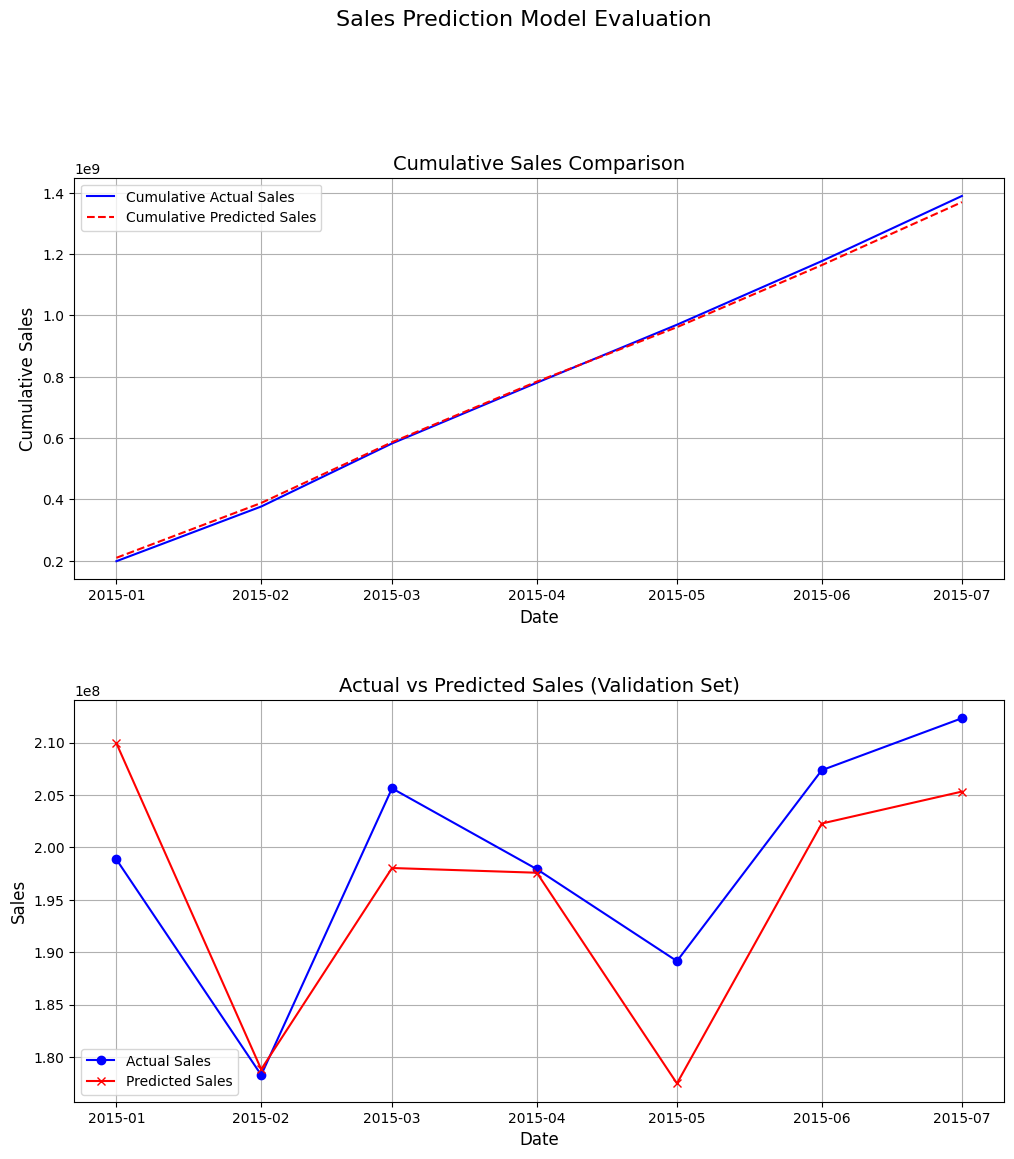

In [86]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'hspace': 0.3},dpi=300)

# Subplot 1
axes[0].plot(val_agg['PseudoDate'], val_agg['Cumulative_Actual_Sales'], label='Cumulative Actual Sales', color='blue')
axes[0].plot(val_agg['PseudoDate'], val_agg['Cumulative_Predicted_Sales'], label='Cumulative Predicted Sales', color='red', linestyle='--')
axes[0].set_title('Cumulative Sales Comparison', fontsize=14)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Cumulative Sales', fontsize=12)
axes[0].legend()
axes[0].grid(True)

# Subplot 2
axes[1].plot(val_agg['PseudoDate'], val_agg['Actual_Sales'], label='Actual Sales', marker='o', color='blue')
axes[1].plot(val_agg['PseudoDate'], val_agg['Predicted_Sales'], label='Predicted Sales', marker='x', color='red')
axes[1].set_title('Actual vs Predicted Sales (Validation Set)', fontsize=14)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Sales', fontsize=12)
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Sales Prediction Model Evaluation', fontsize=16, y=1.02)
plt.show()

* The cumulative actual and predicted sales lines overlap closely, indicating the model accurately tracks long-term sales trends.
* Consistent alignment of cumulative values suggests that any monthly prediction errors (as seen in the bottom graph) do not compound significantly, maintaining overall reliability.
* The model effectively captures month-to-month trends and directional changes, even in months with greater variability. This indicates good generalization to unseen data.

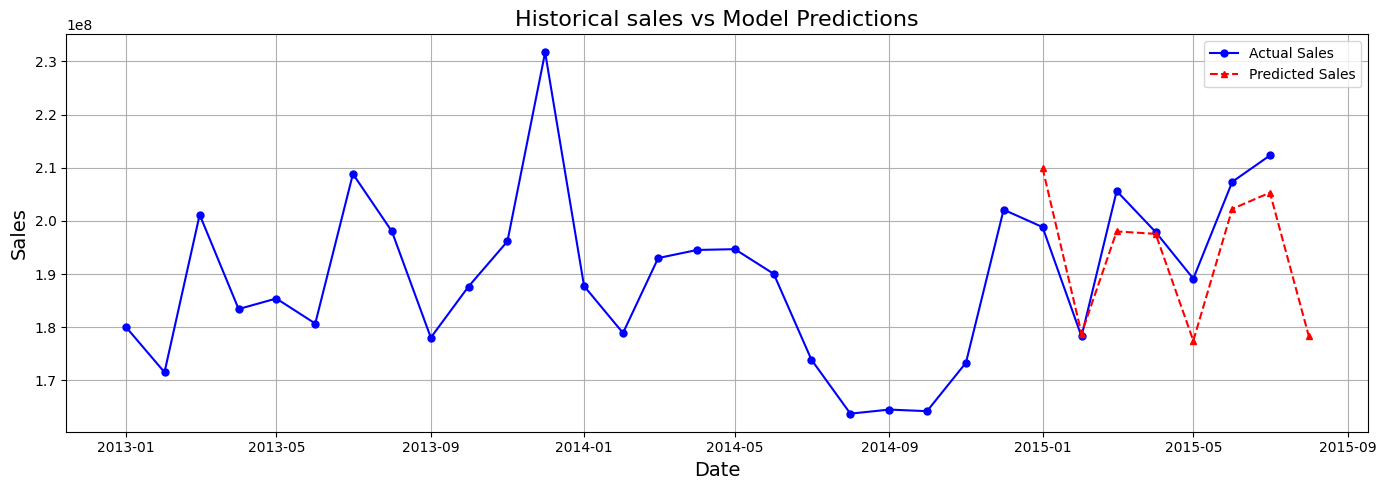

In [87]:
actual_sales = trainEn.assign(
    Date=pd.to_datetime(trainEn['Year'].astype(str) + '-' + trainEn['Month'].astype(str) + '-01')
).groupby('Date')['Sales'].sum().reset_index()

pred_sales = pd.concat([
    X_val.assign(
        Date=pd.to_datetime(X_val['Year'].astype(str) + '-' + X_val['Month'].astype(str) + '-01'),
        Predicted_Sales=y_pred_val_xgb
    ),
    X_test.assign(
        Date=pd.to_datetime(X_test['Year'].astype(str) + '-' + X_test['Month'].astype(str) + '-01'),
        Predicted_Sales=y_pred_test_xgb
    )
])[['Date', 'Predicted_Sales']].groupby('Date').sum().reset_index()

plt.figure(figsize=(14, 5),dpi=300)
plt.plot(
    actual_sales['Date'], 
    actual_sales['Sales'], 
    linestyle='-', marker='o', markersize=5, label='Actual Sales', color='blue'
)

plt.plot(
    pred_sales[pred_sales['Date'] < '2015-09-01']['Date'], 
    pred_sales[pred_sales['Date'] < '2015-09-01']['Predicted_Sales'], 
    linestyle='--', marker='^', markersize=5, label='Predicted Sales', color='red'
)

plt.title('Historical sales vs Model Predictions', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sales', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

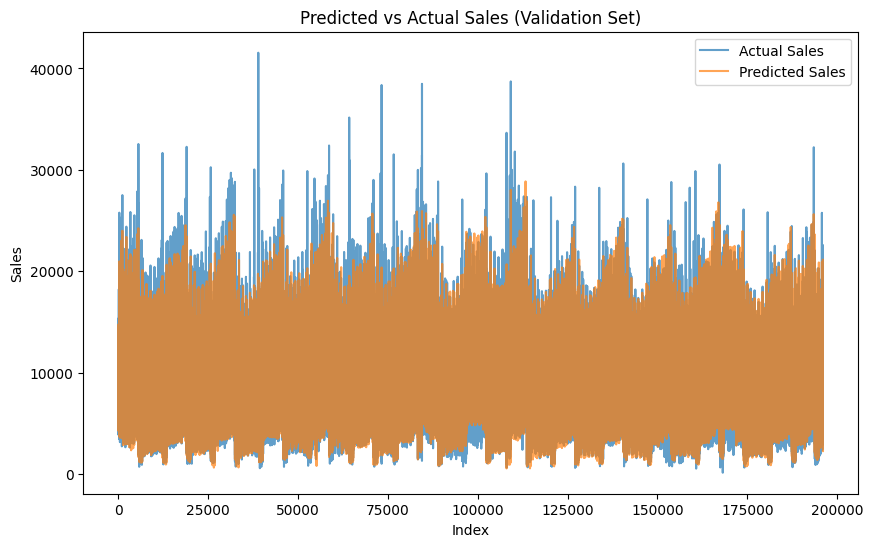

In [88]:
plt.figure(figsize=(10, 6),dpi=300)
plt.plot(y_val.values, label="Actual Sales", alpha=0.7)
plt.plot(y_pred_val_xgb, label="Predicted Sales", alpha=0.7)
plt.title("Predicted vs Actual Sales (Validation Set)")
plt.xlabel("Index")
plt.ylabel("Sales")
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

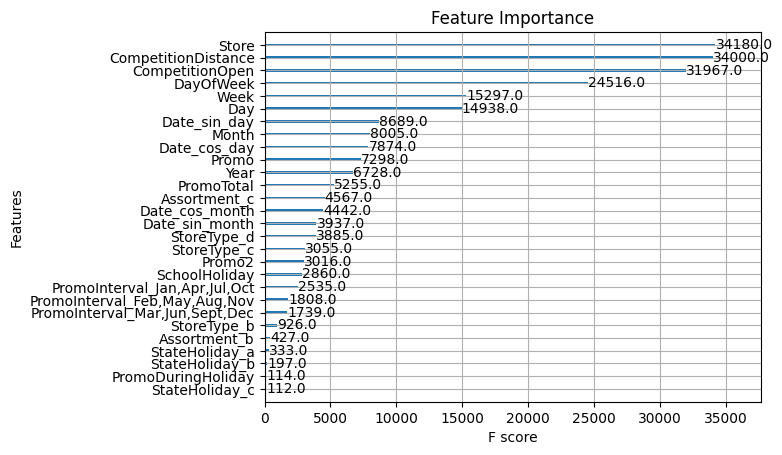

In [89]:
from xgboost import plot_importance

plt.figure(figsize=(10, 8),dpi=300)
plot_importance(xgb_model, max_num_features=30, importance_type='weight', title='Feature Importance')
plt.show()

This feature importance plot reveals several key insights about what drives sales in this retail dataset:

1. The top 4 most influential features are:
- Store (specific store location)
- CompetitionDistance (distance to nearest competitor)
- DayOfWeek 
- CompetitionOpen (whether competitors are open)

2. Surprisingly, promotional factors (Promo, Promo2, PromoInterval) have relatively lower importance compared to structural factors like store location and competition.

3. The holiday features (StateHoliday, SchoolHoliday) appear at the bottom of the chart with relatively low F scores, suggesting they have minimal impact on sales prediction despite what we observed in the earlier graphs.

4. Temporal features like Month, Week, and various date encodings (sin/cos transformations) show moderate importance, indicating seasonality plays a role but isn't the dominant factor.

5. Store characteristics (StoreType, Assortment) fall in the middle range of importance, suggesting they influence sales but not as strongly as location and competition factors.

This visualization suggests that physical and competitive factors are more crucial for predicting sales than promotional activities or seasonal events. This could be valuable for strategic decision-making around store locations and competitive positioning.

### 4.3 Prophet

In [90]:
sd2 = train.sample(frac=0.2, random_state=1)
prophetDf = sd2.rename(columns = {'Date': 'ds',
                                'Sales': 'y'})

In [91]:
split_date = '2015-01-01'  
train_data = prophetDf[prophetDf['ds'] < split_date]
test_data = prophetDf[prophetDf['ds'] >= split_date]

In [92]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

my_model = Prophet(interval_width=0.95)
my_model.fit(train_data)

future = my_model.make_future_dataframe(periods=len(test_data), freq='D')
forecast = my_model.predict(future)

test_predictions = forecast[forecast['ds'].isin(test_data['ds'])]
aligned_data = pd.merge(test_data, test_predictions[['ds', 'yhat']], on='ds', how='inner')

mae = mean_absolute_error(aligned_data['y'], aligned_data['yhat'])
rmse = mean_squared_error(aligned_data['y'], aligned_data['yhat'], squared=False)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

18:07:40 - cmdstanpy - INFO - Chain [1] start processing
18:08:40 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Error (MAE): 2981.0011191599656
Root Mean Squared Error (RMSE): 3561.319045898555


In [93]:
fc = forecast[['ds', 'yhat']].rename(columns = {'Date': 'ds', 'Forecast': 'yhat'})

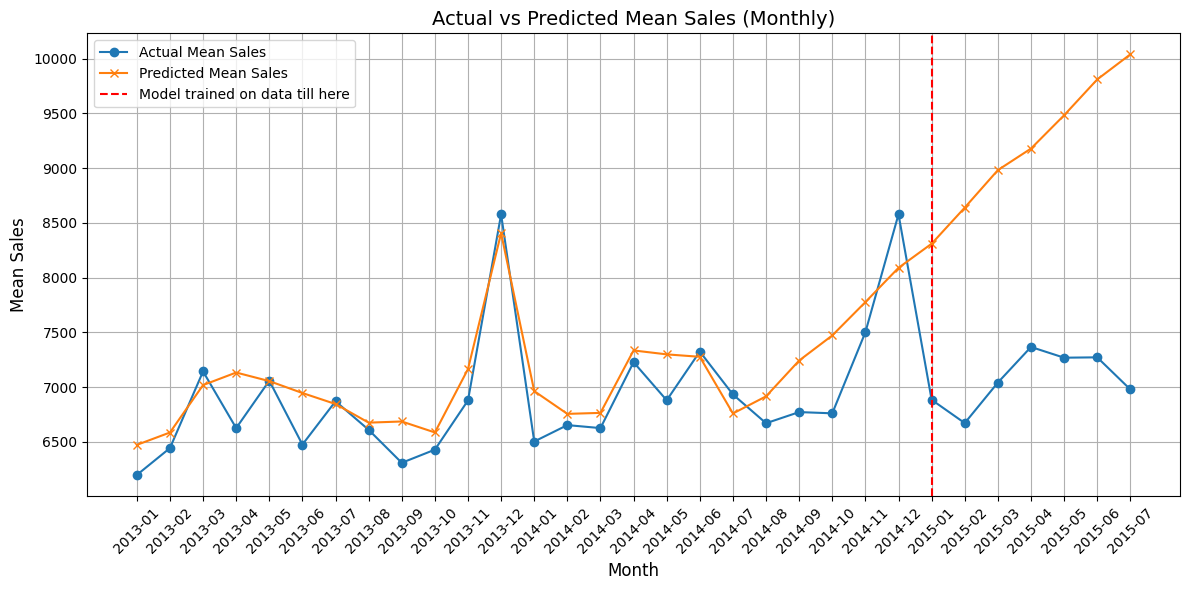

In [96]:
prophetDf['month'] = pd.to_datetime(prophetDf['ds']).dt.to_period('M')
actual_monthly_sales = prophetDf.groupby('month')['y'].mean().reset_index()
actual_monthly_sales['month'] = actual_monthly_sales['month'].astype(str)

forecast['month'] = pd.to_datetime(forecast['ds']).dt.to_period('M')
predicted_monthly_sales = forecast.groupby('month')['yhat'].mean().reset_index()
predicted_monthly_sales['month'] = predicted_monthly_sales['month'].astype(str)

comparison_df = pd.merge(
    actual_monthly_sales,
    predicted_monthly_sales,
    on='month',
    how='inner'
)

comparison_df.rename(
    columns={'y': 'Actual Mean Sales', 'yhat': 'Predicted Mean Sales'},
    inplace=True
)

plt.figure(figsize=(12, 6),dpi=300)
plt.plot(comparison_df['month'], comparison_df['Actual Mean Sales'], label='Actual Mean Sales', marker='o')
plt.plot(comparison_df['month'], comparison_df['Predicted Mean Sales'], label='Predicted Mean Sales', marker='x')

plt.axvline(x='2015-01', color='red', linestyle='--', label='Model trained on data till here')

plt.title('Actual vs Predicted Mean Sales (Monthly)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Mean Sales', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

Model was trained on data from 2013 to 2015, from 1.1.2015 model is making predictions on unseen data.

For the forecast period (after the red line), Prophet's predictions show a strong upward trend that completely misses the actual pattern. Prophet is not be capturing the underlying patterns in the sales data effectively.

## 5. Conclusion

**Model accuracy**
   * XGBoost strongly outperforms Prophet and Linear Regression
   * Model achieved 96% training score, indicating it explains most of the variation in the sales data
   * On average, predictions deviate from actual sales by about 11% of the mean sales value - this is a moderate error level for sales forecasting
   * Prophet has shown the worst accuracy, suggesting time based predictions, without accounting for other featuers is insufficent

**Expansion Strategy**

* Focus new store openings in high-density areas, regardless of competition
* Convert more locations to store type 'b' format where feasible
* Expand product assortment across stores, prioritizing lower-performing locations

**Operational Optimization**

* Adjust staffing and inventory for Monday peaks
* Consider extending Sunday hours in high-traffic locations
* Implement broader product assortment in stores showing growth potential
  
**Promotion Strategy**

* More promotions in underperforming stores could lift sales
* Time major promotions with holiday periods, especially Easter
* Target promotions to counter slower sales days (Thursday-Saturday)